# Práctica 1: Clasificación de Imágenes Portuarias
**Miguel Baños Baladrón — Fiz Garrido Escudero**

---

# 1. Análisis Exploratorio del Dataset

Antes de diseñar cualquier clasificador, es fundamental entender el dataset con el que vamos a trabajar. Este análisis tiene dos objetivos:

1. **Caracterizar** la composición del dataset: distribución de clases, variedad visual, condiciones de captura.
2. **Justificar** las decisiones de diseño: estrategia de *data augmentation*, manejo del desbalance de clases y elección del modelo base.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from PIL import Image

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 10

In [4]:
IMAGE_PATH = r"C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\P1-Material\images"
SHIP_CSV   = r"C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\P1-Material\ship.csv"
DOCKED_CSV = r"C:\Users\Pc\Desktop\Uni\Tercero\segundo_cuatri\VCA\VCA\P1-Material\docked.csv"

## 1.1 Composición y Distribución de Clases

El dataset contiene **294 imágenes** capturadas por cámaras en entornos portuarios. Cada imagen tiene asociadas dos etiquetas:

- **Ship / No-Ship**: indica si hay algún barco visible en la escena.
- **Docked / Undocked**: indica si el barco (cuando existe) está atracado.

El primer paso es cuantificar el **balance de clases**, ya que un desbalance significativo puede sesgar el entrenamiento hacia la clase mayoritaria.

In [5]:
ship_df   = pd.read_csv(SHIP_CSV, sep=';', header=0, names=['filename', 'ship'])
docked_df = pd.read_csv(DOCKED_CSV, sep=';', header=0, names=['filename', 'docked'])

df = ship_df.merge(docked_df, on='filename', how='left')
df['docked'] = df['docked'].fillna(-1).astype(int) # Rellenamos imágenes sin barco con -1 
df['filepath'] = df['filename'].apply(lambda f: os.path.join(IMAGE_PATH, f)) 

ship_mask = df['ship'] == 1 # Máscara para imágenes con barcos
noship_mask = df['ship'] == 0 # Máscara para imágenes sin barcos
docked_mask = (df['ship'] == 1) & (df['docked'] == 1) # Máscara para imágenes con barcos atracados
undocked_mask = (df['ship'] == 1) & (df['docked'] == 0) # Máscara para imágenes con barcos no atracados

n_total = len(df)
n_ship = ship_mask.sum()
n_noship = noship_mask.sum()
n_docked = docked_mask.sum()
n_undocked = undocked_mask.sum()

print(f"{'Total imágenes:'}: {n_total}")
print(f"{'Ship'}: {n_ship} ({n_ship/n_total*100:.1f}%)")
print(f"{'No-Ship'}: {n_noship} ({n_noship/n_total*100:.1f}%)")
print(f"{'Docked'}: {n_docked} ({n_docked/n_ship*100:.1f}% de las ship)")
print(f"{'Undocked'}: {n_undocked} ({n_undocked/n_ship*100:.1f}% de las ship)")

Total imágenes:: 294
Ship: 184 (62.6%)
No-Ship: 110 (37.4%)
Docked: 92 (50.0% de las ship)
Undocked: 92 (50.0% de las ship)


**Observaciones:**

- Existe un **desbalance moderado** en Ship/No-Ship (~63% vs ~37%). No es extremo, pero implica que un clasificador trivial que predijera siempre "Ship" alcanzaría ya un 62.6% de *accuracy*, lo que hace que esta métrica por sí sola sea insuficiente para evaluar el modelo.
- Las clases Docked/Undocked están **perfectamente balanceadas** (50%/50%), por lo que en esa tarea el desbalance no es un problema y la *accuracy* es una métrica más fiable.
- Para Ship/No-Ship se valorará el uso de `pos_weight` en `BCEWithLogitsLoss` para compensar el desbalance, junto con un split estratificado que mantenga las proporciones en train y test.

## 1.2 Muestras Representativas por Categoría

La distribución numérica dice poco sobre la dificultad real del problema. Para entender qué hace difícil la clasificación, necesitamos ver las imágenes. En particular, queremos verificar si:

- Existen **casos ambiguos** (p. ej. un barco muy pequeño al fondo, o un muelle sin barco que parece tenerlo).
- La **variabilidad intraclase** es alta (imágenes de la misma categoría que lucen muy distintas entre sí).
- Hay **patrones de fondo** que el modelo podría aprender de forma incorrecta (*correlaciones espurias*).

Las imágenes se seleccionan distribuidas uniformemente por índice para mostrar variedad, no casos extremos.

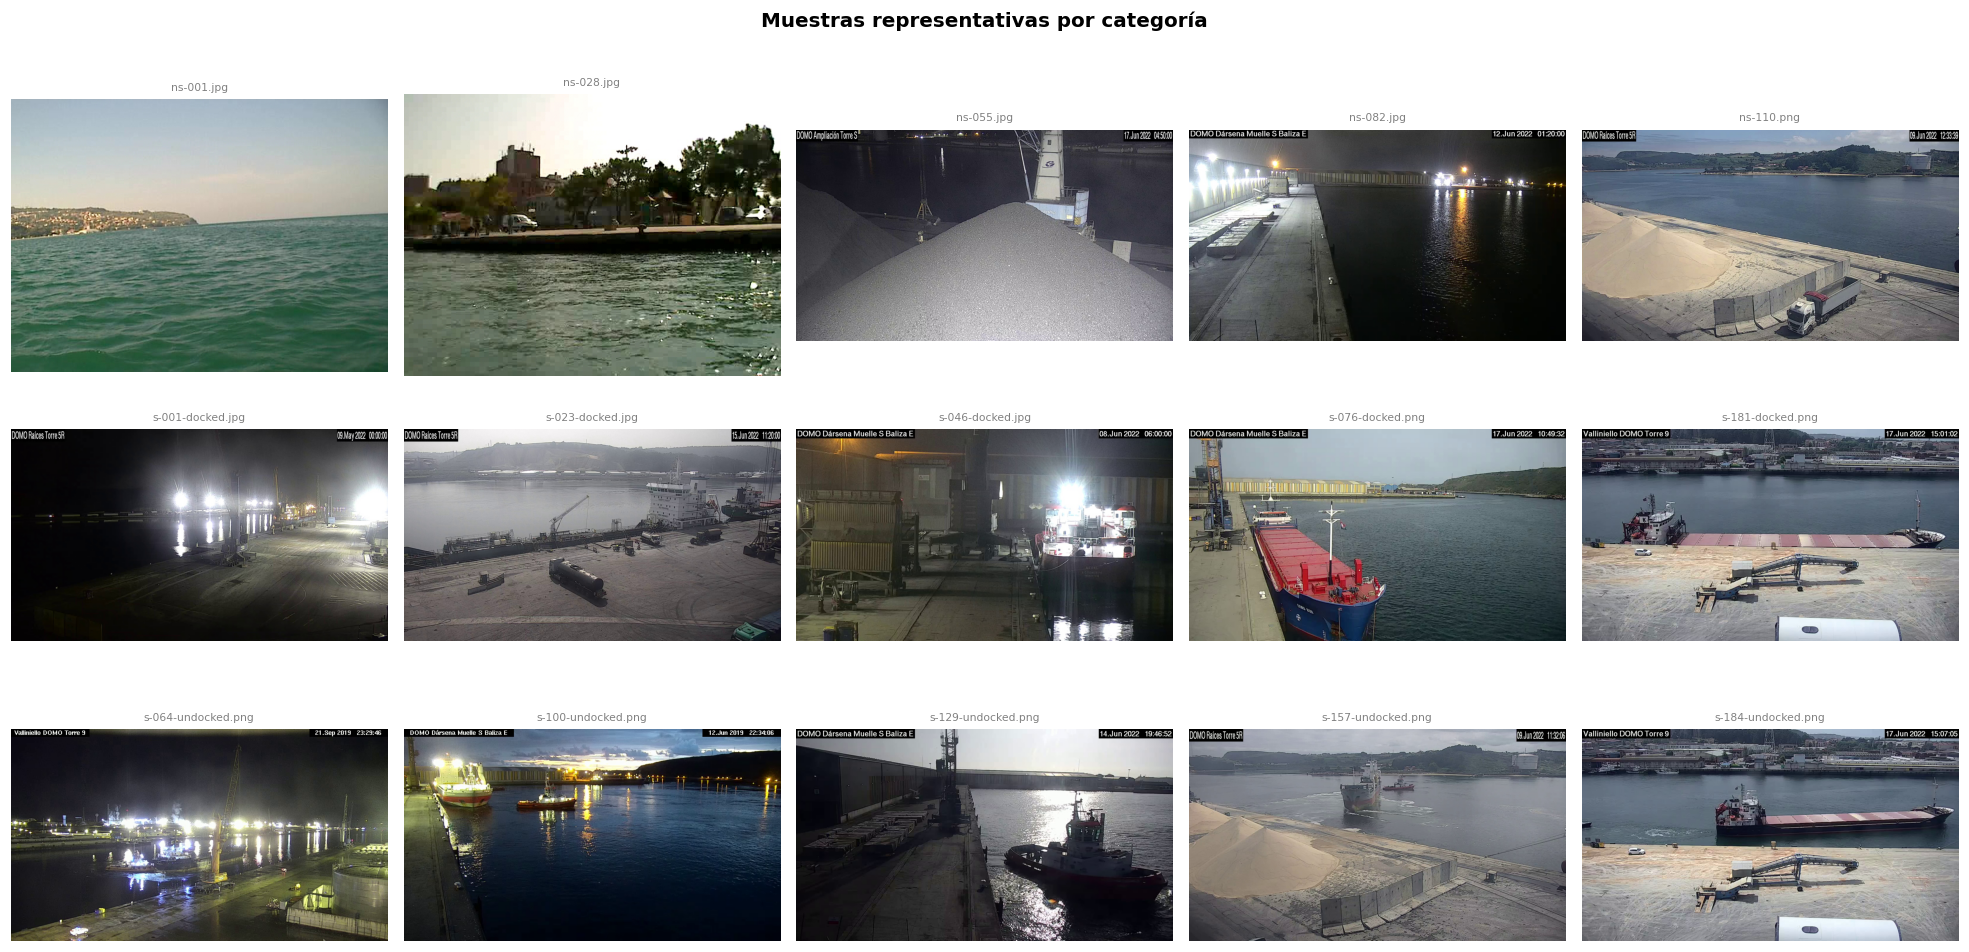

In [6]:
# Función para seleccionar n imágenes distribuidas a lo largo de la lista
def pick_spread(file_list, n=5):
    idx = np.linspace(0, len(file_list) - 1, n, dtype=int) # índices equiespaciados
    result = []
    for i in idx:
        result.append(file_list[i])
    return result

noship_files = df[noship_mask]['filepath'].tolist() # Lista de archivos sin barco
docked_files = df[docked_mask]['filepath'].tolist() # Lista de archivos con barco atracado
undocked_files = df[undocked_mask]['filepath'].tolist() # Lista de archivos con barco no atracado

# Seleccionamos 5 imágenes de cada categoría
N_COLS = 5
row_data = [
    (pick_spread(noship_files, N_COLS), 'No-Ship', 'steelblue'),
    (pick_spread(docked_files, N_COLS), 'Ship — Docked', 'mediumseagreen'),
    (pick_spread(undocked_files, N_COLS), 'Ship — Undocked', 'coral'),
]

fig, axes = plt.subplots(3, N_COLS, figsize=(18, 9))
fig.suptitle('Muestras representativas por categoría', 
             fontsize=13, fontweight='bold', y=1.01)

for row_i, (files, label, color) in enumerate(row_data):
    for col_j, fp in enumerate(files):
        img = Image.open(fp).convert('RGB')
        axes[row_i][col_j].imshow(img)
        axes[row_i][col_j].axis('off')
        axes[row_i][col_j].set_title(os.path.basename(fp), fontsize=7, color='gray')
    # Etiqueta de la fila
    axes[row_i][0].set_ylabel(label, fontsize=11, fontweight='bold',
                               rotation=90, labelpad=8, color=color)

plt.tight_layout()
plt.show()

**Observaciones:**

- Las imágenes presentan una **alta variabilidad intraclase**: distintos ángulos de cámara, distancias al sujeto, escalas del barco y condiciones de iluminación dentro de la misma categoría.
- Algunos casos de **No-Ship** muestran muelles, aguas y estructuras portuarias que podrían confundirse fácilmente con escenas con barco pequeño o parcialmente visible.
- La distinción **Docked/Undocked** es visualmente más sutil: en ambos casos hay un barco en escena; la diferencia está en la presencia de amarres, la posición relativa al muelle y detalles contextuales que requieren features de alto nivel.
- Esta variabilidad justifica el uso de **transfer learning** (features preentrenadas en ImageNet) y de **data augmentation** agresivo, en lugar de entrenar desde cero con un dataset tan pequeño.

## 1.3 Análisis de Condiciones de Captura

En el dataset tenemos imágenes con **condiciones meteorológicas variables**. Esto introduce una heterogeneidad visual importante que el clasificador debe ser capaz de manejar:

- **Hora del día**: imágenes diurnas (alta iluminación) o nocturnas (baj iluminación).
- **Condiciones atmosféricas**: días despejados, niebla, lluvia,... que reducen el contraste y la saturación de color.

Sin etiquetado manual de condiciones, podemos **estimarlas a partir de estadísticas de píxeles**:

| Estadística | Qué mide | Condición que indica |
|---|---|---|
| **Brillo medio** | Luminancia promedio (0–255) | Bajo → noche ; Alto → día despejado |
| **Contraste** (σ de luminancia) | Variabilidad tonal | Bajo → niebla, lluvia, cielo cubierto |
| **Saturación media** | Pureza del color (0–1) | Baja → condiciones de poca luz, lluvia o niebla que desatura los colores |

In [6]:
# Función para calcular estadísticas de brillo, contraste y saturación
def compute_stats(filepath):
    img = Image.open(filepath).convert('RGB')
    arr = np.array(img, dtype=np.float32)

    # Luminancia perceptual (pesos BT.601)
    gray = 0.299 * arr[:, :, 0] + 0.587 * arr[:, :, 1] + 0.114 * arr[:, :, 2]
    brightness = gray.mean()
    contrast   = gray.std()

    # Saturación: (max_canal - min_canal) / max_canal  (HSV-style)
    arr_norm = arr / 255.0
    cmax = arr_norm.max(axis=2)
    cmin = arr_norm.min(axis=2)
    delta = cmax - cmin
    sat = np.where(cmax > 1e-6, delta / cmax, 0.0)
    saturation = sat.mean()

    return brightness, contrast, saturation

print("Calculando estadísticas de píxeles...")
rows = []
for _, row in df.iterrows():
    b, c, s = compute_stats(row['filepath'])
    rows.append({
        'filename':   row['filename'],
        'filepath':   row['filepath'],
        'ship':       row['ship'],
        'docked':     row['docked'],
        'brightness': b,
        'contrast':   c,
        'saturation': s,
    })

df_stats = pd.DataFrame(rows)
print("Listo.\n")

Calculando estadísticas de píxeles...


C:\Users\Pc\AppData\Local\Temp\ipykernel_28612\3856244442.py:16: RuntimeWarning: invalid value encountered in divide
  sat = np.where(cmax > 1e-6, delta / cmax, 0.0)


Listo.



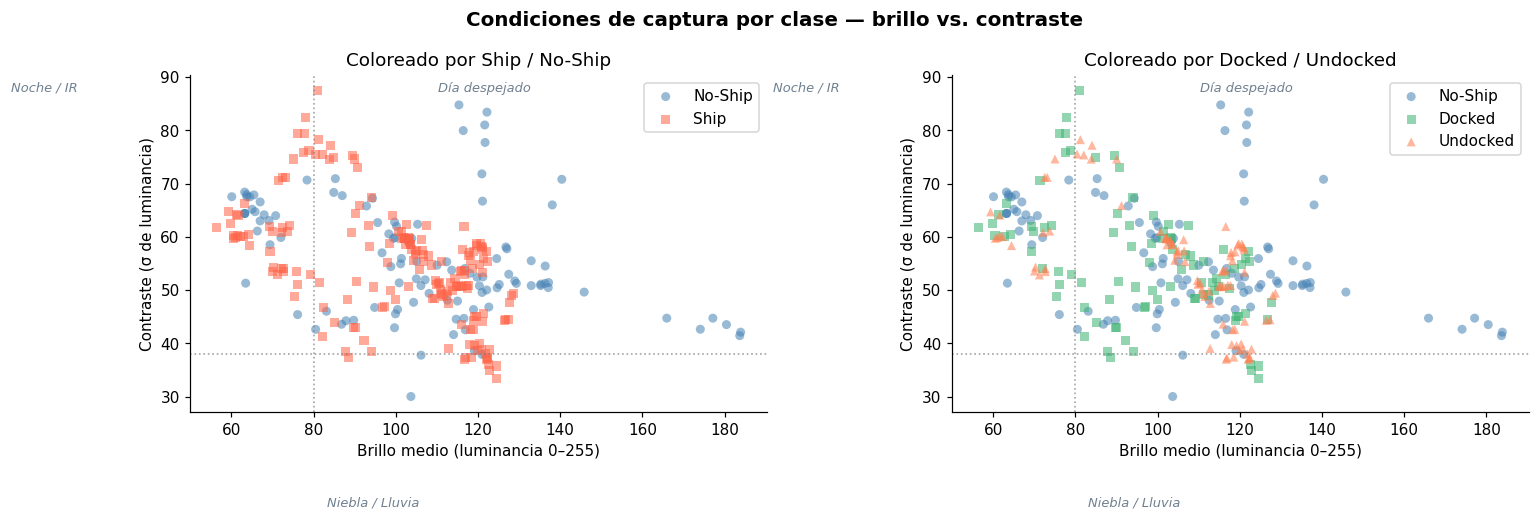

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Condiciones de captura por clase — brillo vs. contraste', 
             fontsize=13, fontweight='bold')

class_cfg = [
    (0, 'No-Ship',  'steelblue',     'o'),
    (1, 'Ship',     'tomato',        's'),
]

for ax_idx, ax in enumerate(axes):
    for cls, label, color, marker in class_cfg:
        mask = df_stats['ship'] == cls
        ax.scatter(df_stats[mask]['brightness'], df_stats[mask]['contrast'],
                   c=color, label=label, alpha=0.55, s=35, marker=marker, edgecolors='none')

    # Umbrales orientativos
    THR_B, THR_C = 80, 38
    ax.axvline(THR_B, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)
    ax.axhline(THR_C, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)

    y_top = df_stats['contrast'].max() * 1.05
    ax.text(THR_B * 0.08, y_top * 0.95, 'Noche / IR',          fontsize=8.5, color='slategray', style='italic')
    ax.text(THR_B * 1.04, THR_C * 0.25, 'Niebla / Lluvia',     fontsize=8.5, color='slategray', style='italic')
    ax.text(df_stats['brightness'].max() * 0.6, y_top * 0.95, 'Día despejado', fontsize=8.5, color='slategray', style='italic')

    ax.set_xlabel('Brillo medio (luminancia 0–255)')
    ax.set_ylabel('Contraste (σ de luminancia)')
    ax.legend()

# El segundo eje colorea por Docked/Undocked
axes[1].clear()
docked_cfg = [
    (-1, 'No-Ship',  'steelblue',     'o'),
    (1,  'Docked',   'mediumseagreen','s'),
    (0,  'Undocked', 'coral',         '^'),
]
for cls, label, color, marker in docked_cfg:
    mask = df_stats['docked'] == cls
    axes[1].scatter(df_stats[mask]['brightness'], df_stats[mask]['contrast'],
                    c=color, label=label, alpha=0.55, s=35, marker=marker, edgecolors='none')

axes[1].axvline(THR_B, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)
axes[1].axhline(THR_C, color='gray', linestyle=':', linewidth=1.1, alpha=0.7)
axes[1].text(THR_B * 0.08, y_top * 0.95, 'Noche / IR',       fontsize=8.5, color='slategray', style='italic')
axes[1].text(THR_B * 1.04, THR_C * 0.25, 'Niebla / Lluvia',  fontsize=8.5, color='slategray', style='italic')
axes[1].text(df_stats['brightness'].max() * 0.6, y_top * 0.95, 'Día despejado', fontsize=8.5, color='slategray', style='italic')
axes[1].set_xlabel('Brillo medio (luminancia 0–255)')
axes[1].set_ylabel('Contraste (σ de luminancia)')
axes[1].legend()

axes[0].set_title('Coloreado por Ship / No-Ship')
axes[1].set_title('Coloreado por Docked / Undocked')

plt.tight_layout()
plt.show()

**Observaciones:**

- El dataset cubre un **rango amplio de condiciones**: desde imágenes nocturnas (brillo < 80) hasta imágenes diurnas muy iluminadas (brillo >= 100).
- Las imágenes de bajo contraste (σ < 50) con brillo moderado corresponden a condiciones de **niebla o lluvia**.
- Las distribuciones de condiciones es, en general, igual independientemente de las clases. Sin embargo, podemos ver que no hay imágenes sin barco y muy brillantes (>130). Por lo que puede inferir la presencia de un barco aunque no lo haya, simplemente por el brillo de la imagen
- Esta variabilidad justifica un *data augmentation* que incluya **`ColorJitter` con rangos amplios** (para simular distintas horas del día y climas) y **`GaussianBlur`** (para simular niebla o distancias largas).

# 2. Dataset Personalizado

La clase `PortDataset` usa el DataFrame construido en el análisis para integrarse con los `DataLoader` de PyTorch. Sirve para ambas tareas de clasificación:

- **Ship/No-Ship** (`label_col='ship'`): usa todas las imágenes.
- **Docked/Undocked** (`label_col='docked'`): filtra automáticamente solo las imágenes con barco.

El split train/val es **estratificado** para preservar las proporciones de clase observadas en el análisis.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class PortDataset(Dataset):
    def __init__(self, df, label_col='ship', transform=None):
        if label_col == 'docked':
            self.df = df[df['ship'] == 1].reset_index(drop=True) # Para Docked/Undocked solo usamos imágenes con barco
        else:
            self.df = df.reset_index(drop=True)

        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx] # Obtenemos la fila correspondiente al índice
        img = Image.open(row['filepath']).convert('RGB') # Cargamos la imagen
        label = torch.tensor(row[self.label_col], dtype=torch.float32) # Obtenemos la etiqueta

        if self.transform:
            img = self.transform(img)

        return img, label

In [8]:
from sklearn.model_selection import train_test_split

# Split estratificado 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['ship'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['ship'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df= test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} imágenes")
print(f"Val: {len(val_df)} imágenes")
print(f"Test: {len(test_df)} imágenes")

# Transforms
transform_base = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

Train: 205 imágenes
Val: 44 imágenes
Test: 45 imágenes


Número de muestras: 205
Tensor shape : torch.Size([3, 224, 224])
Label        : 1.0
Dtype imagen : torch.float32


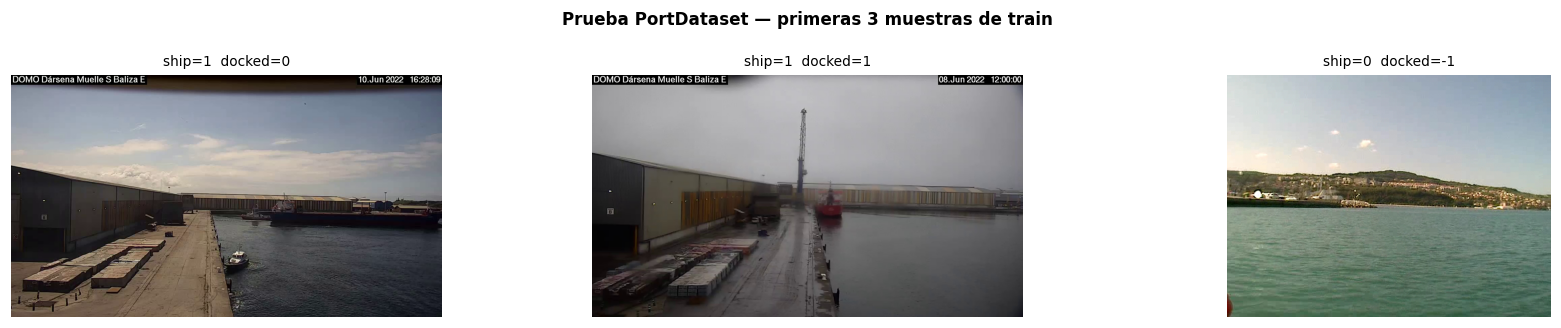

In [15]:
# --- Prueba de PortDataset ---
ds_prueba = PortDataset(train_df, label_col='ship', transform=transform_base)

print(f"Número de muestras: {len(ds_prueba)}")

img, label = ds_prueba[0]
print(f"Tensor shape : {img.shape}")   # esperado: torch.Size([3, 224, 224])
print(f"Label        : {label}")       # esperado: tensor(0.) o tensor(1.)
print(f"Dtype imagen : {img.dtype}")   # esperado: torch.float32

# Muestra imágenes del dataset con sus etiquetas
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for i, ax in enumerate(axes):
    row = train_df.iloc[i]
    ax.imshow(Image.open(row['filepath']).convert('RGB'))
    ax.set_title(f"ship={row['ship']}  docked={row['docked']}", fontsize=9)
    ax.axis('off')
plt.suptitle('Prueba PortDataset — primeras 3 muestras de train', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Clasificación Ship / No-Ship

## 3.1 Arquitectura base

Red convolucional de 3 bloques. Cada bloque sigue el patrón `Conv → BN → ReLU → MaxPool`. El clasificador final es una única neurona con `BCEWithLogitsLoss`, que internamente aplica sigmoid — más estable numéricamente que aplicarlo manualmente.

In [1]:
import torch
import torch.nn as nn

# Arquitectura CNN base
class BaseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloque 1: 3 → 16
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 224 → 112

            # Bloque 2: 16 → 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 112 → 56

            # Bloque 3: 32 → 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 56 → 28
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 28×28 → 1×1
            nn.Flatten(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

## 3.2 Funciones de entrenamiento y evaluación

Funciones reutilizables para todos los experimentos. `train_epoch` realiza un paso completo de entrenamiento; `eval_epoch` calcula la pérdida y métricas sobre un conjunto sin actualizar pesos.

In [2]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {DEVICE}")

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.long().cpu().tolist())

    n = len(loader.dataset)
    return total_loss / n, accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, zero_division=0)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)

            total_loss += loss.item() * len(labels)
            probs = torch.sigmoid(logits).cpu().tolist()
            preds = [int(p >= 0.5) for p in probs]
            all_preds.extend(preds)
            all_labels.extend(labels.long().cpu().tolist())
            all_probs.extend(probs)

    n = len(loader.dataset)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else float('nan')
    return total_loss / n, accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, zero_division=0), auc

Usando dispositivo: cpu


## 3.3 Experimento A — BaseCNN desde cero, sin *data augmentation*

**Configuración:**
- Modelo: `BaseCNN`
- Transform: solo resize + normalización (sin augmentation)
- Pérdida: `BCEWithLogitsLoss` con `pos_weight` para compensar el desbalance Ship/No-Ship
- Optimizador: Adam, lr = 1e-3
- Scheduler: ReduceLROnPlateau (paciencia 5, factor 0.5)
- Early stopping: paciencia 15 épocas sobre val_loss
- Épocas máx: 60

In [9]:
import torch.optim as optim

# DataLoaders (sin augmentation)
train_ds_A = PortDataset(train_df, label_col='ship', transform=transform_base)
val_ds_A   = PortDataset(val_df,   label_col='ship', transform=transform_base)

train_loader_A = DataLoader(train_ds_A, batch_size=32, shuffle=True,  num_workers=0)
val_loader_A   = DataLoader(val_ds_A,   batch_size=32, shuffle=False, num_workers=0)

# Modelo, pérdida y optimizador
model_A = BaseCNN().to(DEVICE)

# pos_weight = n_neg / n_pos para compensar el desbalance moderado
n_pos = (train_df['ship'] == 1).sum()
n_neg = (train_df['ship'] == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)

criterion_A = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_A = optim.Adam(model_A.parameters(), lr=1e-3)
scheduler_A = optim.lr_scheduler.ReduceLROnPlateau(optimizer_A, mode='min', patience=5, factor=0.5)

# Bucle de entrenamiento
MAX_EPOCHS = 60
EARLY_STOP = 15

history_A = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(model_A, train_loader_A, criterion_A, optimizer_A)
    va_loss, va_acc, va_f1, va_auc = eval_epoch(model_A, val_loader_A, criterion_A)
    scheduler_A.step(va_loss)

    history_A['train_loss'].append(tr_loss)
    history_A['val_loss'].append(va_loss)
    history_A['train_acc'].append(tr_acc)
    history_A['val_acc'].append(va_acc)
    history_A['train_f1'].append(tr_f1)
    history_A['val_f1'].append(va_f1)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model_A.state_dict(), 'model_A_best.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Época {epoch:3d} | "
              f"loss {tr_loss:.4f}/{va_loss:.4f} | "
              f"acc {tr_acc:.3f}/{va_acc:.3f} | "
              f"f1 {tr_f1:.3f}/{va_f1:.3f} | "
              f"AUC {va_auc:.3f} | "
              f"lr {optimizer_A.param_groups[0]['lr']:.2e}")

    if patience_counter >= EARLY_STOP:
        print(f"\nEarly stopping en época {epoch} (mejor val_loss={best_val_loss:.4f})")
        break

print("\nEntrenamiento completado. Mejor modelo guardado en 'model_A_best.pth'")

Época   1 | loss 0.5013/0.5002 | acc 0.463/0.659 | f1 0.286/0.727 | AUC 0.739 | lr 1.00e-03
Época  10 | loss 0.3402/0.3401 | acc 0.810/0.841 | f1 0.851/0.877 | AUC 0.871 | lr 1.00e-03
Época  20 | loss 0.2946/0.3213 | acc 0.854/0.773 | f1 0.884/0.800 | AUC 0.897 | lr 1.00e-03
Época  30 | loss 0.2749/0.3246 | acc 0.863/0.773 | f1 0.890/0.808 | AUC 0.897 | lr 1.00e-03
Época  40 | loss 0.2184/0.3237 | acc 0.907/0.841 | f1 0.926/0.889 | AUC 0.942 | lr 1.00e-03
Época  50 | loss 0.2057/0.2618 | acc 0.912/0.864 | f1 0.930/0.903 | AUC 0.960 | lr 1.00e-03
Época  60 | loss 0.1740/0.2346 | acc 0.922/0.886 | f1 0.937/0.918 | AUC 0.973 | lr 5.00e-04

Entrenamiento completado. Mejor modelo guardado en 'model_A_best.pth'


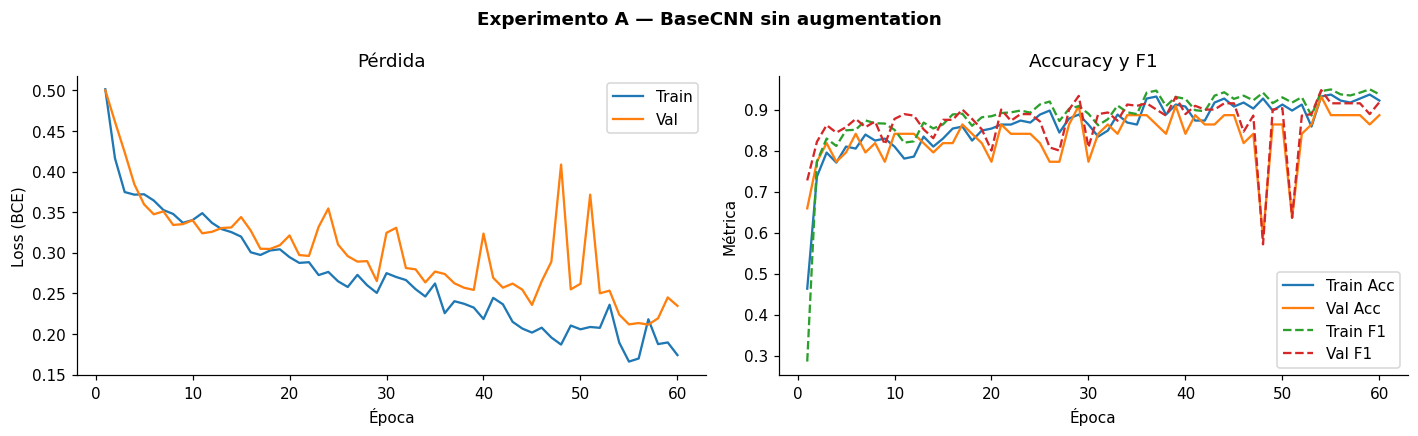

In [10]:
# Curvas de entrenamiento
epochs_ran = range(1, len(history_A['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Experimento A — BaseCNN sin augmentation', fontsize=12, fontweight='bold')

axes[0].plot(epochs_ran, history_A['train_loss'], label='Train')
axes[0].plot(epochs_ran, history_A['val_loss'],   label='Val')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Pérdida'); axes[0].legend()

axes[1].plot(epochs_ran, history_A['train_acc'], label='Train Acc')
axes[1].plot(epochs_ran, history_A['val_acc'],   label='Val Acc')
axes[1].plot(epochs_ran, history_A['train_f1'],  label='Train F1', linestyle='--')
axes[1].plot(epochs_ran, history_A['val_f1'],    label='Val F1',   linestyle='--')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Métrica')
axes[1].set_title('Accuracy y F1'); axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_14104\2054261919.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_A.load_state_dict(torch.load('model_A_best.pth', map_loca

Experimento A · Test
  Loss : 0.3493
  Acc  : 0.9111
  F1   : 0.9310
  AUC  : 0.8634

              precision    recall  f1-score   support

     No-Ship       0.93      0.82      0.88        17
        Ship       0.90      0.96      0.93        28

    accuracy                           0.91        45
   macro avg       0.92      0.89      0.90        45
weighted avg       0.91      0.91      0.91        45



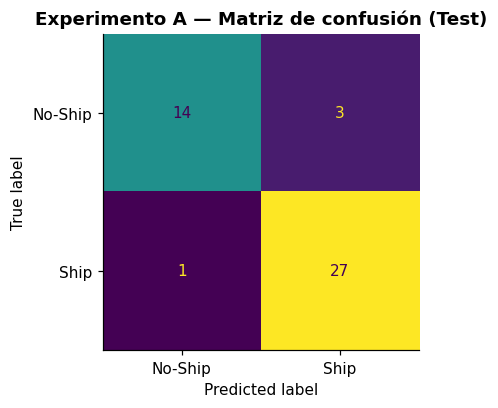

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluación sobre test
test_ds_A   = PortDataset(test_df, label_col='ship', transform=transform_base)
test_loader_A = DataLoader(test_ds_A, batch_size=32, shuffle=False, num_workers=0)

# Cargamos el mejor checkpoint
model_A.load_state_dict(torch.load('model_A_best.pth', map_location=DEVICE))
te_loss, te_acc, te_f1, te_auc = eval_epoch(model_A, test_loader_A, criterion_A)

print(f"Experimento A · Test")
print(f"  Loss : {te_loss:.4f}")
print(f"  Acc  : {te_acc:.4f}")
print(f"  F1   : {te_f1:.4f}")
print(f"  AUC  : {te_auc:.4f}")

# Matriz de confusión
model_A.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader_A:
        imgs = imgs.to(DEVICE)
        logits = model_A(imgs)
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.long().tolist())

print("\n" + classification_report(all_labels, all_preds, target_names=['No-Ship', 'Ship']))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['No-Ship', 'Ship']).plot(ax=ax, colorbar=False)
ax.set_title('Experimento A — Matriz de confusión (Test)', fontweight='bold')
plt.tight_layout()
plt.show()